# Black Friday Purchase Prediction — Regression

## Machine Learning Capstone Project

**Dataset:** Black Friday Dataset  
**Target Variable:** Purchase  
**Problem Type:** Regression

This notebook implements an end-to-end regression pipeline including:
- Exploratory Data Analysis
- Data Cleaning
- Feature Engineering
- Data Preprocessing
- Training and Comparison of 10 Regression Algorithms
- Hyperparameter Tuning
- Model Evaluation
- Cross-Validation
- Regression Visualizations

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
import warnings
warnings.filterwarnings("ignore")


In [2]:
df = pd.read_csv("E:/SEM-5/ML/ML-PROJECT/ML-Capstone-Project/data/Black Friday Dataset.csv")

In [3]:
df.head()

,User_ID,Product_ID,Gender,Age,Occupation,City_Category,Stay_In_Current_City_Years,Marital_Status,Product_Category_1,Product_Category_2,Product_Category_3,Purchase
0,1000001,P00069042,F,0-17,10,A,2,0,3,NaN,NaN,8370
1,1000001,P00248942,F,0-17,10,A,2,0,1,6.0,14.0,15200
2,1000001,P00087842,F,0-17,10,A,2,0,12,NaN,NaN,1422
3,1000001,P00085442,F,0-17,10,A,2,0,12,14.0,NaN,1057
4,1000002,P00285442,M,55+,16,C,4+,0,8,NaN,NaN,7969


In [4]:
print("Dataset Shape:", df.shape)

print("\nColumn Names:")
print(df.columns.tolist())

print("\nData Types:")
print(df.dtypes)

Dataset Shape: (550068, 12)

Column Names:
['User_ID', 'Product_ID', 'Gender', 'Age', 'Occupation', 'City_Category', 'Stay_In_Current_City_Years', 'Marital_Status', 'Product_Category_1', 'Product_Category_2', 'Product_Category_3', 'Purchase']

Data Types:
User_ID                         int64
Product_ID                        str
Gender                            str
Age                               str
Occupation                      int64
City_Category                     str
Stay_In_Current_City_Years        str
Marital_Status                  int64
Product_Category_1              int64
Product_Category_2            float64
Product_Category_3            float64
Purchase                        int64
dtype: object


In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 550068 entries, 0 to 550067
Data columns (total 12 columns):
 #   Column                      Non-Null Count   Dtype  
---  ------                      --------------   -----  
 0   User_ID                     550068 non-null  int64  
 1   Product_ID                  550068 non-null  str    
 2   Gender                      550068 non-null  str    
 3   Age                         550068 non-null  str    
 4   Occupation                  550068 non-null  int64  
 5   City_Category               550068 non-null  str    
 6   Stay_In_Current_City_Years  550068 non-null  str    
 7   Marital_Status              550068 non-null  int64  
 8   Product_Category_1          550068 non-null  int64  
 9   Product_Category_2          376430 non-null  float64
 10  Product_Category_3          166821 non-null  float64
 11  Purchase                    550068 non-null  int64  
dtypes: float64(2), int64(5), str(5)
memory usage: 50.4 MB


In [6]:
df.isnull().sum()

User_ID                            0
Product_ID                         0
Gender                             0
Age                                0
Occupation                         0
City_Category                      0
Stay_In_Current_City_Years         0
Marital_Status                     0
Product_Category_1                 0
Product_Category_2            173638
Product_Category_3            383247
Purchase                           0
dtype: int64

In [7]:
df.duplicated().sum()

np.int64(0)

## Target Variable Distribution

The target variable for this regression problem is `Purchase`.

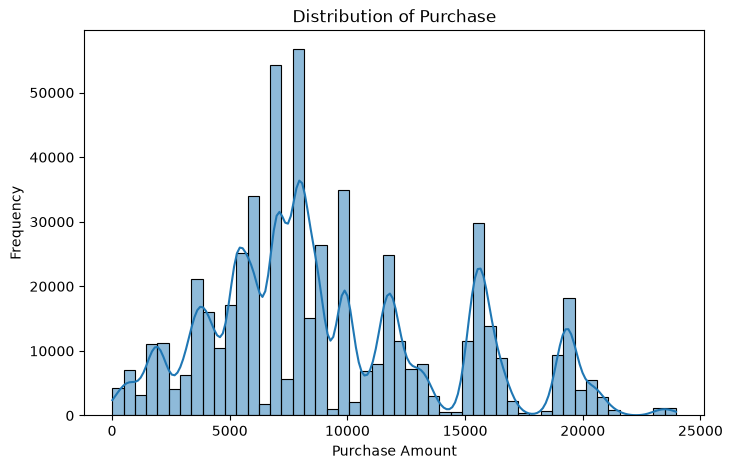

In [8]:
plt.figure(figsize=(8, 5))
sns.histplot(df["Purchase"], bins=50, kde=True)
plt.title("Distribution of Purchase")
plt.xlabel("Purchase Amount")
plt.ylabel("Frequency")
plt.show()

## Distribution of Features

The distributions of all predictor variables

In [9]:
numerical_features = df.select_dtypes(include=np.number).columns.tolist()
categorical_features = df.select_dtypes(include="object").columns.tolist()
numerical_features.remove("Purchase")
print("Numerical Features:")
print(numerical_features)
print("\nCategorical Features:")
print(categorical_features)

Numerical Features:
['User_ID', 'Occupation', 'Marital_Status', 'Product_Category_1', 'Product_Category_2', 'Product_Category_3']

Categorical Features:
['Product_ID', 'Gender', 'Age', 'City_Category', 'Stay_In_Current_City_Years']


## Numerical feature distributions

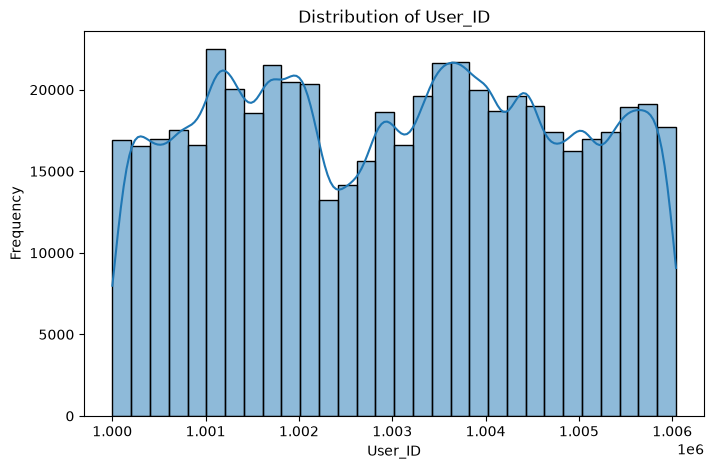

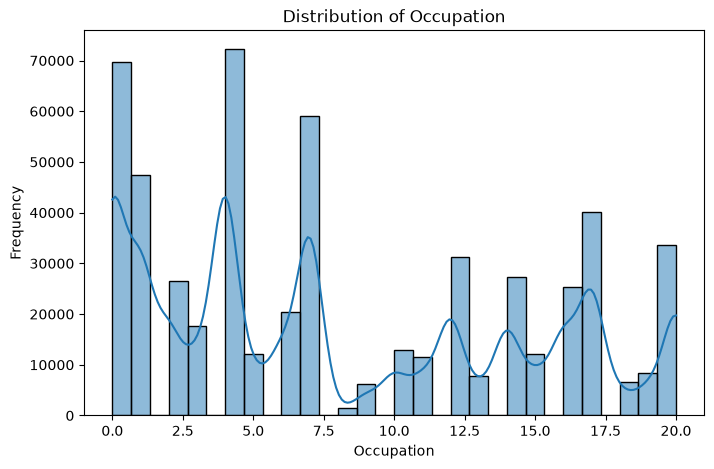

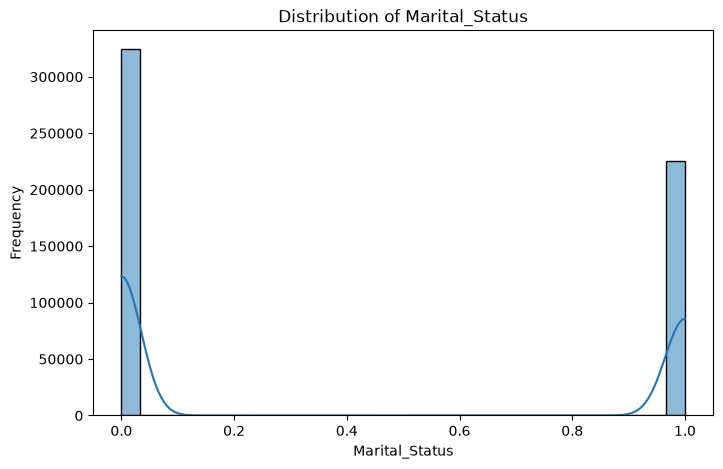

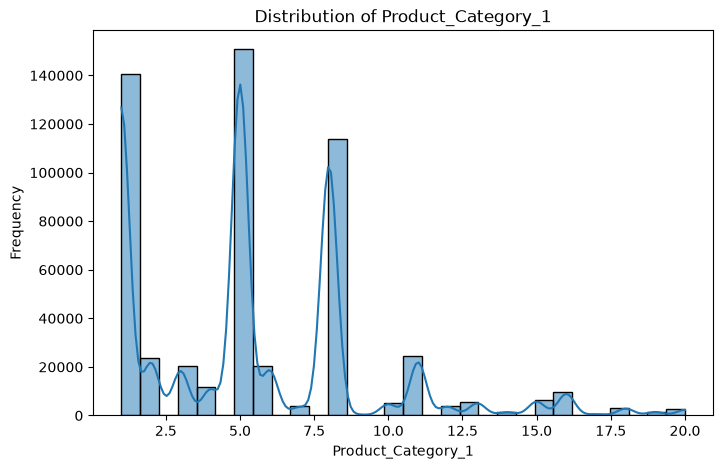

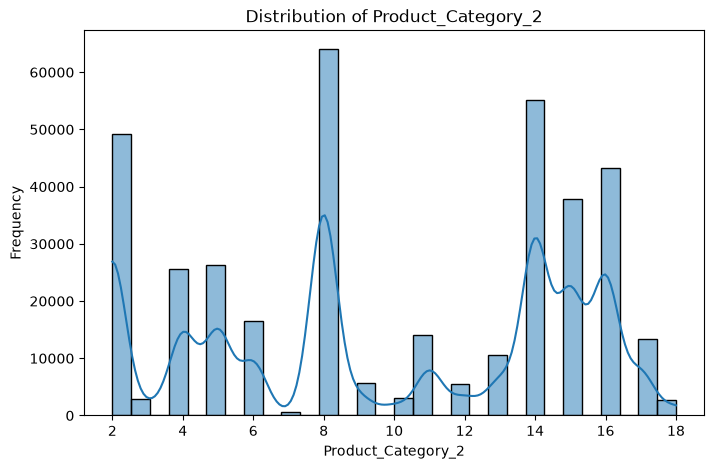

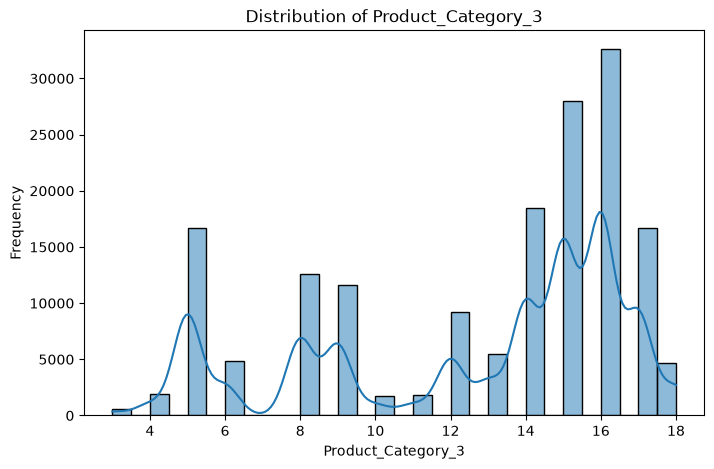

In [10]:
for feature in numerical_features:
    plt.figure(figsize=(8, 5))
    sns.histplot(df[feature], bins=30, kde=True)
    plt.title(f"Distribution of {feature}")
    plt.xlabel(feature)
    plt.ylabel("Frequency")
    plt.show()

## Categorical feature distributions

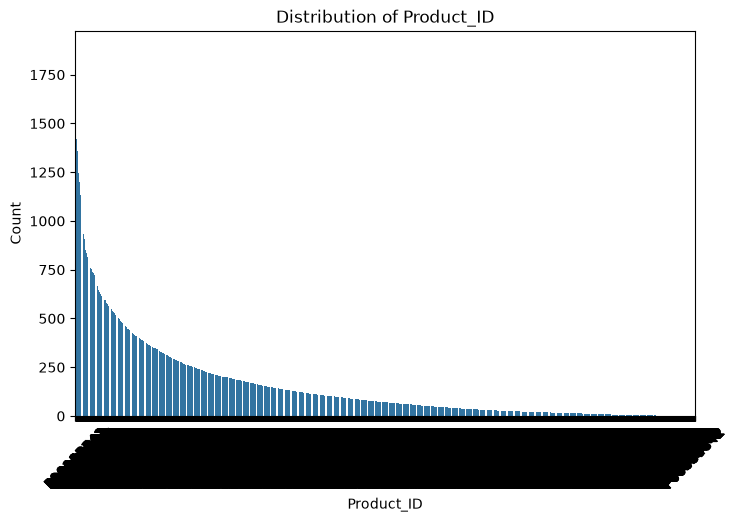

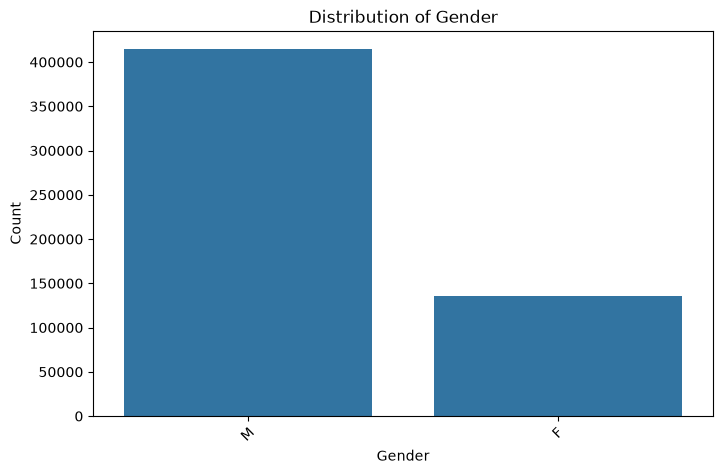

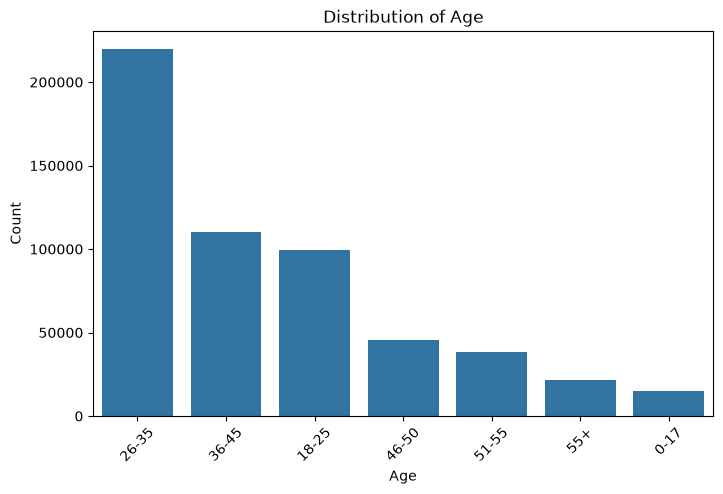

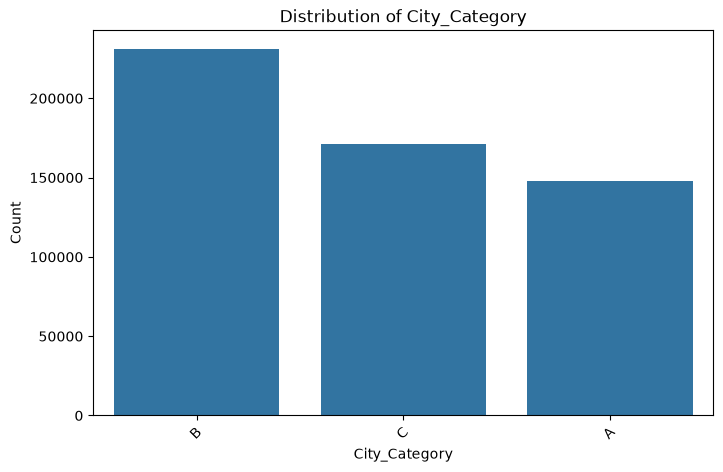

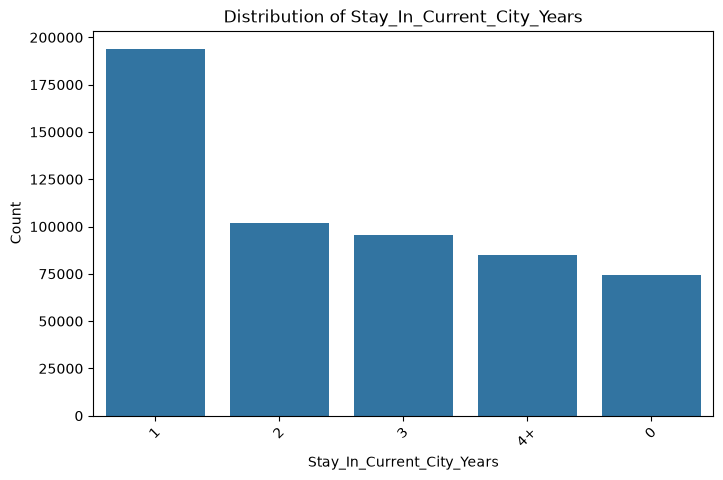

In [11]:
for feature in categorical_features:
    plt.figure(figsize=(8, 5))
    sns.countplot(data=df,x=feature,order=df[feature].value_counts().index)
    plt.title(f"Distribution of {feature}")
    plt.xlabel(feature)
    plt.ylabel("Count")
    plt.xticks(rotation=45)
    plt.show()

## Relation Between Age and Purchase

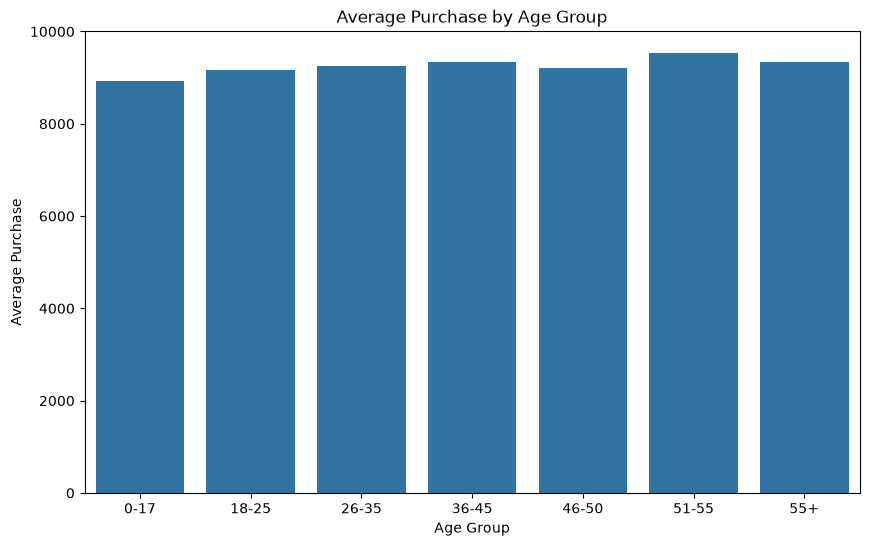

In [12]:
age_purchase = df.groupby("Age")["Purchase"].mean().reset_index()
plt.figure(figsize=(10, 6))
sns.barplot(data=age_purchase,x="Age",y="Purchase")
plt.xlabel("Age Group")
plt.ylabel("Average Purchase")
plt.title("Average Purchase by Age Group")
plt.show()

## Relation Between Occupation and Purchase

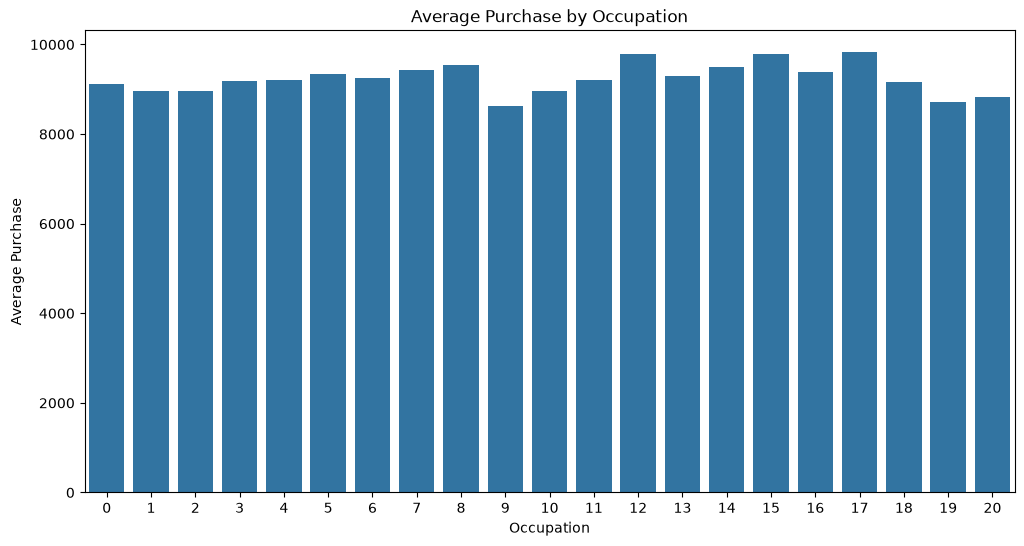

In [13]:
occupation_purchase = df.groupby("Occupation")["Purchase"].mean().reset_index()
plt.figure(figsize=(12, 6))
sns.barplot(data=occupation_purchase,x="Occupation",y="Purchase")
plt.xlabel("Occupation")
plt.ylabel("Average Purchase")
plt.title("Average Purchase by Occupation")
plt.show()

## Correlation Heatmap

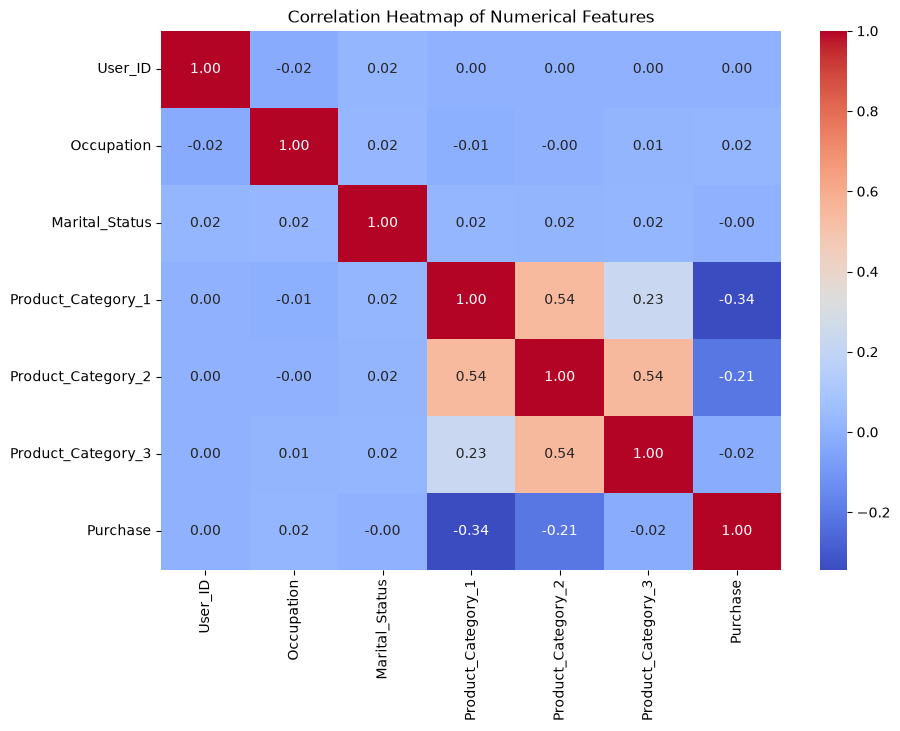

In [14]:
plt.figure(figsize=(10, 7))
correlation_matrix = df[numerical_features + ["Purchase"]].corr()
sns.heatmap(correlation_matrix,annot=True,cmap="coolwarm",fmt=".2f")
plt.title("Correlation Heatmap of Numerical Features")
plt.show()

## Feature-Target Relationship: Product Category 1

A scatter plot is used to examine the relationship between Product_Category_1 and the target variable Purchase.

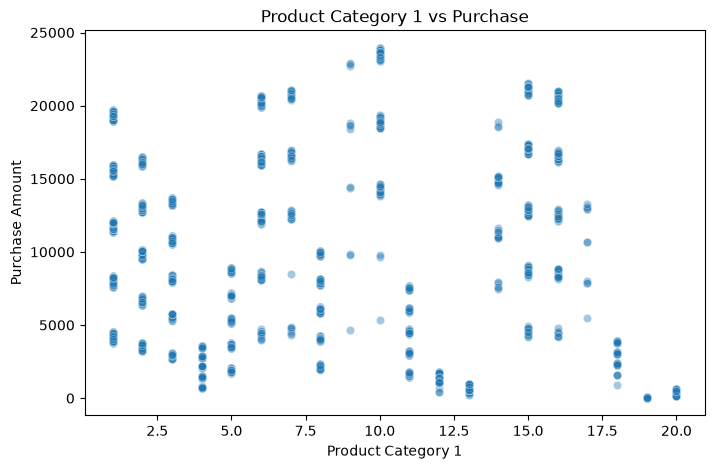

In [15]:
plot_sample = df.sample(10000, random_state=42)
plt.figure(figsize=(8, 5))
sns.scatterplot(data=plot_sample,x="Product_Category_1",y="Purchase",alpha=0.4)
plt.title("Product Category 1 vs Purchase")
plt.xlabel("Product Category 1")
plt.ylabel("Purchase Amount")
plt.show()

## Feature-Target Relationship: Occupation

A second scatter plot is used to examine the relationship between Occupation and Purchase.

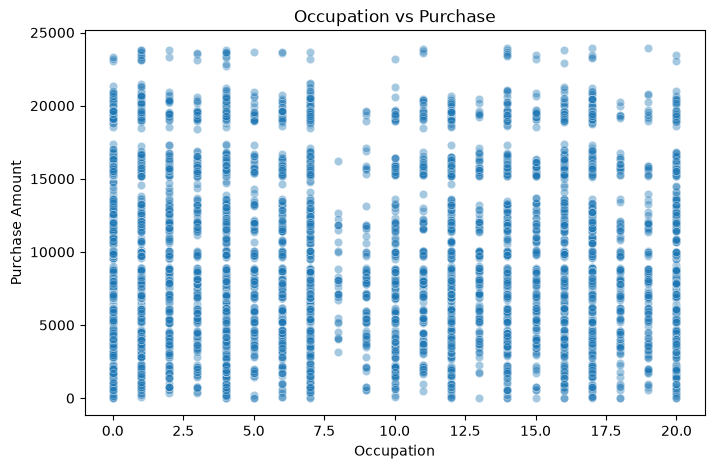

In [16]:
plt.figure(figsize=(8, 5))
sns.scatterplot(data=plot_sample,x="Occupation",y="Purchase",alpha=0.4)
plt.title("Occupation vs Purchase")
plt.xlabel("Occupation")
plt.ylabel("Purchase Amount")
plt.show()

### Section B
## Data Cleaning

The dataset contains missing values in `Product_Category_2` and
`Product_Category_3`. Since these are numerical product-category variables,
their missing values are replaced using the median of each column.

The median is used because it is less sensitive to extreme values than the
mean and allows us to retain the available observations.

In [17]:
df.isnull().sum()

User_ID                            0
Product_ID                         0
Gender                             0
Age                                0
Occupation                         0
City_Category                      0
Stay_In_Current_City_Years         0
Marital_Status                     0
Product_Category_1                 0
Product_Category_2            173638
Product_Category_3            383247
Purchase                           0
dtype: int64

In [18]:
df["Product_Category_2"] = df["Product_Category_2"].fillna(df["Product_Category_2"].median())
df["Product_Category_3"] = df["Product_Category_3"].fillna(df["Product_Category_3"].median())

In [19]:
df.isnull().sum()

User_ID                       0
Product_ID                    0
Gender                        0
Age                           0
Occupation                    0
City_Category                 0
Stay_In_Current_City_Years    0
Marital_Status                0
Product_Category_1            0
Product_Category_2            0
Product_Category_3            0
Purchase                      0
dtype: int64

In [20]:
df.duplicated().sum()

np.int64(0)

## Outlier Detection

Outliers are checked using the Interquartile Range (IQR) method. The IQmethod identifies observations lying below Q1 - 1.5 × IQR or above Q3 + 1.5 × IQR.

In [21]:
Q1 = df["Purchase"].quantile(0.25)
Q3 = df["Purchase"].quantile(0.75)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR
outliers = df[(df["Purchase"] < lower_bound) |(df["Purchase"] > upper_bound)]
print("Lower bound:", lower_bound)
print("Upper bound:", upper_bound)
print("Number of outliers:", len(outliers))

Lower bound: -3523.5
Upper bound: 21400.5
Number of outliers: 2677


In [22]:
df["Purchase"].describe()

count    550068.000000
mean       9263.968713
std        5023.065394
min          12.000000
25%        5823.000000
50%        8047.000000
75%       12054.000000
max       23961.000000
Name: Purchase, dtype: float64

In [23]:
df["Purchase"] = df["Purchase"].clip(lower=lower_bound,upper=upper_bound)
outliers1 = df[(df["Purchase"] < lower_bound) |(df["Purchase"] > upper_bound)]
print("Number of outliers:", len(outliers1))

Number of outliers: 0


## Feature Engineering

An `Age_Midpoint` feature is created from the existing age-group variable.Each age range is represented by its midpoint.

This provides an ordered numerical representation of the customer's age group,which may help regression models capture an approximately monotonic
relationship between age and purchase amount.

In [24]:
age_midpoints = {
    "0-17": 8.5,
    "18-25": 21.5,
    "26-35": 30.5,
    "36-45": 40.5,
    "46-50": 48,
    "51-55": 53,
    "55+": 60
}

df["Age_Midpoint"] = df["Age"].map(age_midpoints)
df[["Age", "Age_Midpoint"]].head()

,Age,Age_Midpoint
0,0-17,8.5
1,0-17,8.5
2,0-17,8.5
3,0-17,8.5
4,55+,60.0


## Encoding, Scaling & Splitting

Purchase is continuous, so we cannot directly do stratify=y.so create quantile bins of Purchase and use those bins only for stratification

In [25]:
categorical_columns = ["Gender","Age","City_Category","Stay_In_Current_City_Years"]
df = pd.get_dummies(df,columns=categorical_columns,drop_first=True,dtype=int)

In [26]:
# removing user id and product id
df = df.drop(columns=["User_ID", "Product_ID"])

In [27]:
df.head()

,Occupation,Marital_Status,Product_Category_1,Product_Category_2,Product_Category_3,Purchase,Age_Midpoint,Gender_M,Age_18-25,Age_26-35,Age_36-45,Age_46-50,Age_51-55,Age_55+,City_Category_B,City_Category_C,Stay_In_Current_City_Years_1,Stay_In_Current_City_Years_2,Stay_In_Current_City_Years_3,Stay_In_Current_City_Years_4+
0,10,0,3,9.0,14.0,8370.0,8.5,0,0,0,0,0,0,0,0,0,0,1,0,0
1,10,0,1,6.0,14.0,15200.0,8.5,0,0,0,0,0,0,0,0,0,0,1,0,0
2,10,0,12,9.0,14.0,1422.0,8.5,0,0,0,0,0,0,0,0,0,0,1,0,0
3,10,0,12,14.0,14.0,1057.0,8.5,0,0,0,0,0,0,0,0,0,0,1,0,0
4,16,0,8,9.0,14.0,7969.0,60.0,1,0,0,0,0,0,1,0,1,0,0,0,1


In [28]:
X = df.drop(columns="Purchase")
Y = df["Purchase"]

print("Features shape:", X.shape)
print("Target shape:", Y.shape)

Features shape: (550068, 19)
Target shape: (550068,)


In [29]:
y_bins = pd.qcut(
    Y,
    q=10,
    labels=False,
    duplicates="drop"
)

print(y_bins.value_counts().sort_index())

Purchase
0    55008
1    55049
2    55032
3    54985
4    55068
5    54985
6    54924
7    55046
8    54970
9    55001
Name: count, dtype: int64


## Train Test Split

In [30]:
X_train, X_test, Y_train, Y_test = train_test_split(
    X,
    Y,
    test_size=0.20,
    random_state=42,
    stratify=y_bins
)

print("Training set:", X_train.shape)
print("Testing set:", X_test.shape)

Training set: (440054, 19)
Testing set: (110014, 19)


## Scaling
Standardization is applied to the feature variables so that numerical features are placed on a comparable scale. The scaler is fitted only on the training set and then used to transform both the training and testing sets.

In [31]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)
print("Scaled training set:", X_train_scaled.shape)
print("Scaled testing set:", X_test_scaled.shape)

Scaled training set: (440054, 19)
Scaled testing set: (110014, 19)


## Regression Model Implementation

Ten regression algorithms are trained using the same preprocessed training data and evaluated on the same held-out test set. Predictions from each model are used to calculate R², RMSE, and MAE for comparative evaluation.

In [32]:
from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNet
from sklearn.preprocessing import PolynomialFeatures
from sklearn.pipeline import make_pipeline
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.svm import SVR, LinearSVR
from sklearn.neighbors import KNeighborsRegressor

### Linear Regression

Linear Regression models the relationship between the input features and the continuous target variable `Purchase` using a linear function.

In [33]:
linear_model = LinearRegression()
linear_model.fit(X_train_scaled, Y_train)
linear_pred = linear_model.predict(X_test_scaled)
print("Linear Regression completed.")

Linear Regression completed.


In [34]:
linear_coefficients = pd.Series(linear_model.coef_,index=X.columns).sort_values(ascending=False)
linear_coefficients.head(15)

City_Category_C                  332.246516
Gender_M                         217.680262
Age_Midpoint                     194.899640
Age_26-35                         93.100414
City_Category_B                   79.599347
Age_18-25                         58.666607
Age_51-55                         55.121984
Age_36-45                         46.158829
Occupation                        44.376027
Stay_In_Current_City_Years_2      23.321729
Stay_In_Current_City_Years_1      17.129762
Stay_In_Current_City_Years_3      15.465752
Stay_In_Current_City_Years_4+     15.051379
Age_46-50                         -6.864170
Age_55+                          -24.397098
dtype: float64

### Ridge Regression

Ridge Regression is a regularized form of linear regression that adds an L2 penalty to reduce the effect of large coefficients and help control
overfitting.

In [35]:
ridge_results = []

for alpha in [0.01, 0.1, 1, 10, 100]:

    rmodel = Ridge(alpha=alpha)
    rmodel.fit(X_train_scaled, Y_train)
    predictions = rmodel.predict(X_test_scaled)

    ridge_results.append({
        "Model": "Ridge",
        "Alpha": alpha,
        "R²": r2_score(Y_test, predictions),
        "RMSE": np.sqrt(mean_squared_error(Y_test, predictions)),
        "MAE": mean_absolute_error(Y_test, predictions)
    })

ridge_results_df = pd.DataFrame(ridge_results)
ridge_results_df

,Model,Alpha,R²,RMSE,MAE
0,Ridge,0.01,0.129307,4661.074437,3580.580766
1,Ridge,0.10,0.129307,4661.074437,3580.580816
2,Ridge,1.00,0.129307,4661.074433,3580.581312
3,Ridge,10.00,0.129307,4661.074398,3580.586280
4,Ridge,100.00,0.129307,4661.074062,3580.635968


In [36]:
best_ridge_row = ridge_results_df.loc[ridge_results_df["R²"].idxmax()]
best_ridge_alpha = best_ridge_row["Alpha"]
print("Best Ridge Alpha:", best_ridge_alpha)
print("Best R²:", best_ridge_row["R²"])
print("Best RMSE:", best_ridge_row["RMSE"])
print("Best MAE:", best_ridge_row["MAE"])

Best Ridge Alpha: 100.0
Best R²: 0.1293070943288015
Best RMSE: 4661.07406194504
Best MAE: 3580.6359676803404


In [37]:
ridge_model = Ridge(alpha=best_ridge_alpha)
ridge_model.fit(X_train_scaled, Y_train)
ridge_pred = ridge_model.predict(X_test_scaled)
print("Ridge Regression completed.")

Ridge Regression completed.


### Lasso Regression

Lasso Regression applies L1 regularization, which can reduce the influence of less important features by shrinking their coefficients toward zero.

In [38]:
lasso_results = []

for alpha in [ 0.01, 0.1, 1,10,100]:

    lmodel = Lasso(alpha=alpha, max_iter=5000)
    lmodel.fit(X_train_scaled, Y_train)
    predictions = lmodel.predict(X_test_scaled)

    lasso_results.append({
        "Model": "Lasso",
        "Alpha": alpha,
        "R²": r2_score(Y_test, predictions),
        "RMSE": np.sqrt(mean_squared_error(Y_test, predictions)),
        "MAE": mean_absolute_error(Y_test, predictions)
    })

lasso_results_df = pd.DataFrame(lasso_results)
lasso_results_df

,Model,Alpha,R²,RMSE,MAE
0,Lasso,0.01,0.129307,4661.074383,3580.580912
1,Lasso,0.10,0.129307,4661.073774,3580.582552
2,Lasso,1.00,0.129307,4661.073750,3580.604509
3,Lasso,10.00,0.129180,4661.414488,3581.362352
4,Lasso,100.00,0.126822,4667.721796,3598.702858


In [39]:
best_lasso_row = lasso_results_df.loc[lasso_results_df["R²"].idxmax()]
best_lasso_alpha = best_lasso_row["Alpha"]
print("Best Lasso Alpha:", best_lasso_alpha)
print("Best R²:", best_lasso_row["R²"])
print("Best RMSE:", best_lasso_row["RMSE"])
print("Best MAE:", best_lasso_row["MAE"])

Best Lasso Alpha: 1.0
Best R²: 0.1293072110319209
Best RMSE: 4661.073749572045
Best MAE: 3580.604509419149


In [40]:
lasso_model = Lasso(alpha=best_lasso_alpha,max_iter=5000)
lasso_model.fit(X_train_scaled, Y_train)
lasso_pred = lasso_model.predict(X_test_scaled)
print("Lasso Regression completed.")

Lasso Regression completed.


In [41]:
lasso_coefficients = pd.Series(lasso_model.coef_,index=X.columns)
zero_coefficients = (lasso_coefficients == 0).sum()
non_zero_coefficients = (lasso_coefficients != 0).sum()

print("Zero coefficients:", zero_coefficients)
print("Non-zero coefficients:", non_zero_coefficients)

Zero coefficients: 1
Non-zero coefficients: 18


### ElasticNet Regression

ElasticNet combines L1 and L2 regularization to control model complexity and handle correlated features.

In [42]:
elasticnet_results = []

for alpha in [0.01, 0.1, 1, 10, 100]:

    for l1_ratio in [0.2, 0.5, 0.8]:

        emodel = ElasticNet(alpha=alpha,l1_ratio=l1_ratio,max_iter=5000)
        emodel.fit(X_train_scaled,Y_train)
        predictions = emodel.predict(X_test_scaled)
        elasticnet_results.append({
            "Model": "ElasticNet",
            "Alpha": alpha,
            "L1 Ratio": l1_ratio,
            "R²": r2_score(Y_test, predictions),
            "RMSE": np.sqrt(
                mean_squared_error(
                    Y_test,
                    predictions
                )
            ),
            "MAE": mean_absolute_error(
                Y_test,
                predictions
            )
        })
        
elasticnet_results_df = pd.DataFrame(elasticnet_results)
elasticnet_results_df

,Model,Alpha,L1 Ratio,R²,RMSE,MAE
0,ElasticNet,0.01,0.2,0.129304,4661.083553,3582.533641
1,ElasticNet,0.01,0.5,0.129307,4661.074841,3581.799412
2,ElasticNet,0.01,0.8,0.129308,4661.072405,3581.067708
3,ElasticNet,0.10,0.2,0.128664,4662.795068,3600.333442
4,ElasticNet,0.10,0.5,0.129045,4661.775663,3592.934124
5,ElasticNet,0.10,0.8,0.129268,4661.178854,3585.490846
6,ElasticNet,1.00,0.2,0.107082,4720.187889,3735.233093
7,ElasticNet,1.00,0.5,0.116732,4694.611297,3688.551266
8,ElasticNet,1.00,0.8,0.126065,4669.744028,3628.717956
9,ElasticNet,10.00,0.2,0.032263,4913.967309,3976.268655


In [43]:
best_elasticnet_row = elasticnet_results_df.loc[elasticnet_results_df["R²"].idxmax()]
best_elasticnet_alpha = best_elasticnet_row["Alpha"]
best_elasticnet_l1_ratio = best_elasticnet_row["L1 Ratio"]

print("Best ElasticNet Alpha:",best_elasticnet_alpha)
print("Best L1 Ratio:",best_elasticnet_l1_ratio)
print("Best R²:",best_elasticnet_row["R²"])
print("Best RMSE:",best_elasticnet_row["RMSE"])
print("Best MAE:",best_elasticnet_row["MAE"])

Best ElasticNet Alpha: 0.01
Best L1 Ratio: 0.8
Best R²: 0.12930771319007794
Best RMSE: 4661.0724054719385
Best MAE: 3581.0677080822365


In [44]:
elasticnet_model = ElasticNet(alpha=best_elasticnet_alpha,l1_ratio=best_elasticnet_l1_ratio,max_iter=5000)
elasticnet_model.fit(X_train_scaled, Y_train)
elasticnet_pred = elasticnet_model.predict(X_test_scaled)
print("ElasticNet Regression completed.")

ElasticNet Regression completed.


### Polynomial Regression

Polynomial Regression extends linear regression by introducing polynomial terms so that nonlinear relationships between features and the target can
be represented.

In [45]:
polynomial_results = []

for degree in [1, 2]:

    pmodel = make_pipeline(PolynomialFeatures(degree=degree, include_bias=False),LinearRegression())
    pmodel.fit(X_train_scaled, Y_train)
    predictions = pmodel.predict(X_test_scaled)
    
    r2 = r2_score(Y_test, predictions)
    rmse = np.sqrt(mean_squared_error(Y_test, predictions))
    mae = mean_absolute_error(Y_test, predictions)

    polynomial_results.append({
        "Degree": degree,
        "R²": r2,
        "RMSE": rmse,
        "MAE": mae
    })

polynomial_results_df = pd.DataFrame(polynomial_results)
polynomial_results_df

,Degree,R²,RMSE,MAE
0,1,0.129307,4661.074437,3580.580760
1,2,0.229070,4385.923212,3300.406611


In [46]:
best_polynomial_row = polynomial_results_df.loc[polynomial_results_df["R²"].idxmax()]
best_polynomial_degree = int(best_polynomial_row["Degree"])
print("Best Polynomial Degree:", best_polynomial_degree)
print("Best R²:", best_polynomial_row["R²"])
print("Best RMSE:", best_polynomial_row["RMSE"])
print("Best MAE:", best_polynomial_row["MAE"])

Best Polynomial Degree: 2
Best R²: 0.2290698225387755
Best RMSE: 4385.923211585037
Best MAE: 3300.4066111520247


In [47]:
polynomial_model = make_pipeline(PolynomialFeatures(degree=best_polynomial_degree, include_bias=False),LinearRegression())
polynomial_model.fit(X_train_scaled, Y_train)
polynomial_pred = polynomial_model.predict(X_test_scaled)
print("Polynomial Regression completed.")

Polynomial Regression completed.


### Decision Tree Regression

Decision Tree Regression predicts the target by recursively splitting the feature space into regions with similar target values.

In [48]:
decision_tree_model = DecisionTreeRegressor(random_state=42)
decision_tree_model.fit(X_train_scaled, Y_train)
decision_tree_pred = decision_tree_model.predict(X_test_scaled)
print("Decision Tree Regression completed.")

Decision Tree Regression completed.


### Random Forest Regression

Random Forest Regression combines multiple decision trees and averages their predictions to improve predictive performance and reduce overfitting.

In [49]:
random_forest_model = RandomForestRegressor(n_estimators=100,random_state=42,n_jobs=-1)
random_forest_model.fit(X_train_scaled, Y_train)
random_forest_pred = random_forest_model.predict(X_test_scaled)
print("Random Forest Regression completed.")

Random Forest Regression completed.


### Gradient Boosting Regression

Gradient Boosting builds an ensemble of weak prediction models sequentially,where each new model attempts to reduce the errors made by the previous
models.

In [50]:
gradient_boosting_model = GradientBoostingRegressor(random_state=42)
gradient_boosting_model.fit(X_train_scaled, Y_train)
gradient_boosting_pred = gradient_boosting_model.predict(X_test_scaled)
print("Gradient Boosting Regression completed.")

Gradient Boosting Regression completed.


### Support Vector Regression

Support Vector Regression uses the principles of Support Vector Machines to find a function that predicts continuous target values while controlling the
prediction error.

In [51]:
svr_model = LinearSVR(max_iter=10000)
svr_model.fit(X_train_scaled, Y_train)
svr_pred = svr_model.predict(X_test_scaled)
print("Support Vector Regression completed.")

Support Vector Regression completed.


### K-Nearest Neighbors Regression

K-Nearest Neighbors Regression predicts a target value using the target values of nearby observations in the feature space.

In [52]:
knn_results = []

for neighbors in [3, 5, 7, 9, 11,15]:

    kmodel = KNeighborsRegressor(n_neighbors=neighbors,n_jobs=-1)
    kmodel.fit(X_train_scaled, Y_train)
    predictions = kmodel.predict(X_test_scaled)

    knn_results.append({
        "Model": "KNN Regression",
        "Parameter": f"n_neighbors={neighbors}",
        "R²": r2_score(Y_test, predictions),
        "RMSE": np.sqrt(mean_squared_error(Y_test, predictions)),
        "MAE": mean_absolute_error(Y_test, predictions)
    })

knn_results_df = pd.DataFrame(knn_results)
knn_results_df

,Model,Parameter,R²,RMSE,MAE
0,KNN Regression,n_neighbors=3,0.482585,3593.130859,2596.654653
1,KNN Regression,n_neighbors=5,0.502002,3525.066212,2563.318165
2,KNN Regression,n_neighbors=7,0.500269,3531.194187,2572.958442
3,KNN Regression,n_neighbors=9,0.492462,3558.669671,2596.107641
4,KNN Regression,n_neighbors=11,0.482838,3592.253790,2623.825158
5,KNN Regression,n_neighbors=15,0.463269,3659.584037,2679.809893


In [53]:
best_knn_row = knn_results_df.loc[knn_results_df["R²"].idxmax()]
best_knn_k = int(best_knn_row["Parameter"].replace("n_neighbors=", ""))
print("Best K:", best_knn_k)
print("Best R²:", best_knn_row["R²"])
print("Best RMSE:", best_knn_row["RMSE"])
print("Best MAE:", best_knn_row["MAE"])

Best K: 5
Best R²: 0.5020020485410517
Best RMSE: 3525.066212365764
Best MAE: 2563.318164960823


In [54]:
knn_model = KNeighborsRegressor(n_neighbors=best_knn_k, n_jobs=-1)
knn_model.fit(X_train_scaled, Y_train)
knn_pred = knn_model.predict(X_test_scaled)
print("KNN Regression completed.")

KNN Regression completed.


## Support Vector Regression — Computational Experiment

The Black Friday dataset contains more than 550,000 records. Standard RBF-kernel Support Vector Regression is computationally expensive for a dataset of this size.

To demonstrate the implementation of standard SVR without replacing the full-data regression pipeline, a representative subset of the dataset is used for this experiment.

The reduced dataset is split into training and testing sets, followed by feature scaling and standard RBF-kernel SVR training.

In [55]:
svr_sample_size = 10000
X_train_svr = X_train_scaled[:svr_sample_size]
Y_train_svr = Y_train.iloc[:svr_sample_size]
X_test_svr = X_test_scaled[:2000]
Y_test_svr = Y_test.iloc[:2000]

svr_results = []

for kernel in ["linear", "rbf", "poly"]:

    for C in [0.1, 1, 10]:

        svr_model = SVR(kernel=kernel,C=C)
        svr_model.fit(X_train_svr,Y_train_svr)
        predictions = svr_model.predict(X_test_svr)
        svr_results.append({
            "Model": "SVR",
            "Kernel": kernel,
            "C": C,
            "R²": r2_score(Y_test_svr, predictions),
            "RMSE": np.sqrt(
                mean_squared_error(Y_test_svr, predictions)
            ),
            "MAE": mean_absolute_error(
                Y_test_svr, predictions
            )
        })

svr_results_df = pd.DataFrame(svr_results)
svr_results_df

,Model,Kernel,C,R²,RMSE,MAE
0,SVR,linear,0.1,-0.002632,5011.085717,3846.476441
1,SVR,linear,1.0,0.127050,4675.796156,3568.245511
2,SVR,linear,10.0,0.135609,4652.818649,3477.540336
3,SVR,rbf,0.1,-0.055875,5142.417409,3935.517039
4,SVR,rbf,1.0,-0.045177,5116.299575,3915.629582
5,SVR,rbf,10.0,0.033104,4920.971310,3789.942855
6,SVR,poly,0.1,-0.056079,5142.912943,3935.784089
7,SVR,poly,1.0,-0.046615,5119.816343,3918.056175
8,SVR,poly,10.0,0.015944,4964.446625,3806.460714


In [56]:
best_svr_row = svr_results_df.loc[svr_results_df["R²"].idxmax()]

print("Best Kernel:", best_svr_row["Kernel"])
print("Best C:", best_svr_row["C"])
print("Best R²:", best_svr_row["R²"])
print("Best RMSE:", best_svr_row["RMSE"])
print("Best MAE:", best_svr_row["MAE"])

Best Kernel: linear
Best C: 10.0
Best R²: 0.13560897249225867
Best RMSE: 4652.818649243553
Best MAE: 3477.54033596661


In [58]:
best_svr_kernel = best_svr_row["Kernel"]
best_svr_C = best_svr_row["C"]
svr_model1 = SVR(kernel=best_svr_kernel,C=best_svr_C)
svr_model1.fit(X_train_svr,Y_train_svr)
svr_pred1 = svr_model1.predict(X_test_svr)
print("SVR completed.")

SVR completed.


In [59]:
svr_r2 = r2_score(Y_test_svr,svr_pred1)
svr_rmse = np.sqrt(mean_squared_error(Y_test_svr,svr_pred1))
svr_mae = mean_absolute_error(Y_test_svr,svr_pred1)

print("SVR R²:", svr_r2)
print("SVR RMSE:", svr_rmse)
print("SVR MAE:", svr_mae)

SVR R²: 0.13560897249225867
SVR RMSE: 4652.818649243553
SVR MAE: 3477.54033596661


## Computational Limitation of Standard SVR

Standard RBF-kernel SVR was initially attempted on the complete Black Friday training dataset. With more than 550,000 records, the training process became computationally impractical and required substantially more time than the other regression algorithms.

Therefore, standard RBF-kernel SVR was not used in the final full-dataset model comparison. The reduced-dataset experiment above demonstrates the
standard SVR implementation, while the full-data experiment demonstrates its computational limitation for this dataset.

For the main regression comparison, a computationally feasible linear support-vector regression approach was used instead.

## Model Evaluation and Comparison

In [60]:
model_results = []

model_results.append({
    "Model": "Linear Regression",
    "R2": r2_score(Y_test, linear_pred),
    "RMSE": np.sqrt(mean_squared_error(Y_test, linear_pred)),
    "MAE": mean_absolute_error(Y_test, linear_pred)
})

In [61]:
model_results.append({
    "Model": "Ridge",
    "R2": r2_score(Y_test, ridge_pred),
    "RMSE": np.sqrt(mean_squared_error(Y_test, ridge_pred)),
    "MAE": mean_absolute_error(Y_test, ridge_pred)
})

In [62]:
model_results.append({
    "Model": "Lasso",
    "R2": r2_score(Y_test, lasso_pred),
    "RMSE": np.sqrt(mean_squared_error(Y_test, lasso_pred)),
    "MAE": mean_absolute_error(Y_test, lasso_pred)
})

In [63]:
model_results.append({
    "Model": "ElasticNet",
    "R2": r2_score(Y_test, elasticnet_pred),
    "RMSE": np.sqrt(mean_squared_error(Y_test, elasticnet_pred)),
    "MAE": mean_absolute_error(Y_test, elasticnet_pred)
})

In [64]:
model_results.append({
    "Model": "Polynomial Regression",
    "R2": r2_score(Y_test, polynomial_pred),
    "RMSE": np.sqrt(mean_squared_error(Y_test, polynomial_pred)),
    "MAE": mean_absolute_error(Y_test, polynomial_pred)
})

In [65]:
model_results.append({
    "Model": "Decision Tree",
    "R2": r2_score(Y_test, decision_tree_pred),
    "RMSE": np.sqrt(mean_squared_error(Y_test, decision_tree_pred)),
    "MAE": mean_absolute_error(Y_test, decision_tree_pred)
})

In [66]:
model_results.append({
    "Model": "Random Forest",
    "R2": r2_score(Y_test, random_forest_pred),
    "RMSE": np.sqrt(mean_squared_error(Y_test, random_forest_pred)),
    "MAE": mean_absolute_error(Y_test, random_forest_pred)
})

In [67]:
model_results.append({
    "Model": "Gradient Boosting",
    "R2": r2_score(Y_test, gradient_boosting_pred),
    "RMSE": np.sqrt(mean_squared_error(Y_test, gradient_boosting_pred)),
    "MAE": mean_absolute_error(Y_test, gradient_boosting_pred)
})

In [68]:
model_results.append({
    "Model": "SVR",
    "R2": r2_score(Y_test, svr_pred),
    "RMSE": np.sqrt(mean_squared_error(Y_test,svr_pred)),
    "MAE": mean_absolute_error(Y_test,svr_pred)
})

In [69]:
model_results.append({
    "Model": "KNN",
    "R2": r2_score(Y_test, knn_pred),
    "RMSE": np.sqrt(mean_squared_error(Y_test, knn_pred)),
    "MAE": mean_absolute_error(Y_test, knn_pred)
})

In [70]:
results_df = pd.DataFrame(model_results)
results_df = results_df.sort_values(by="R2",ascending=False).reset_index(drop=True)

results_df

,Model,R2,RMSE,MAE
0,Gradient Boosting,0.645298,2974.987530,2260.028480
1,Random Forest,0.631316,3033.058073,2206.391120
2,Decision Tree,0.565835,3291.402807,2331.582313
3,KNN,0.502002,3525.066212,2563.318165
4,Polynomial Regression,0.229070,4385.923212,3300.406611
5,ElasticNet,0.129308,4661.072405,3581.067708
6,Lasso,0.129307,4661.073750,3580.604509
7,Ridge,0.129307,4661.074062,3580.635968
8,Linear Regression,0.129307,4661.074437,3580.580760
9,SVR,0.093257,4756.587662,3482.887532


## Hyperparameter Tuning

Hyperparameter tuning is performed on the best-performing regression models identified from the initial comparison. GridSearchCV is used to systematically evaluate different hyperparameter combinations using the training data.